### Variability Module(3rd in operation order):

Description: Uses some algorithms (provided by CIAO) to determine how much each source
varies over time, and plots the source's light curve. Also gives each source a
“score” ranging from 0 to 10, with higher scores corresponding to sources that are more likely to
be variable.

(NOTE: These light curves are probability-weighted, so they may smooth out noise in order to
produce a (usually) cleaner plot. However, this can lead to some of the plots looking a bit
strange.
To get a plot of the raw data, use js9, upload the event file associated with an observation
(will be named "copy.evt2", after running data through every module), upload a region from that observation’s output folder (“source_id_[#]_index_[#].reg”;
AND only one region at a time), and in the analysis tab, click upload fits to enable server-side
tasks. This will enable a light curve option in the analysis tab which makes a light curve for this
one single region.)


### Expected Results:
Returns the following for each source in the input region file:

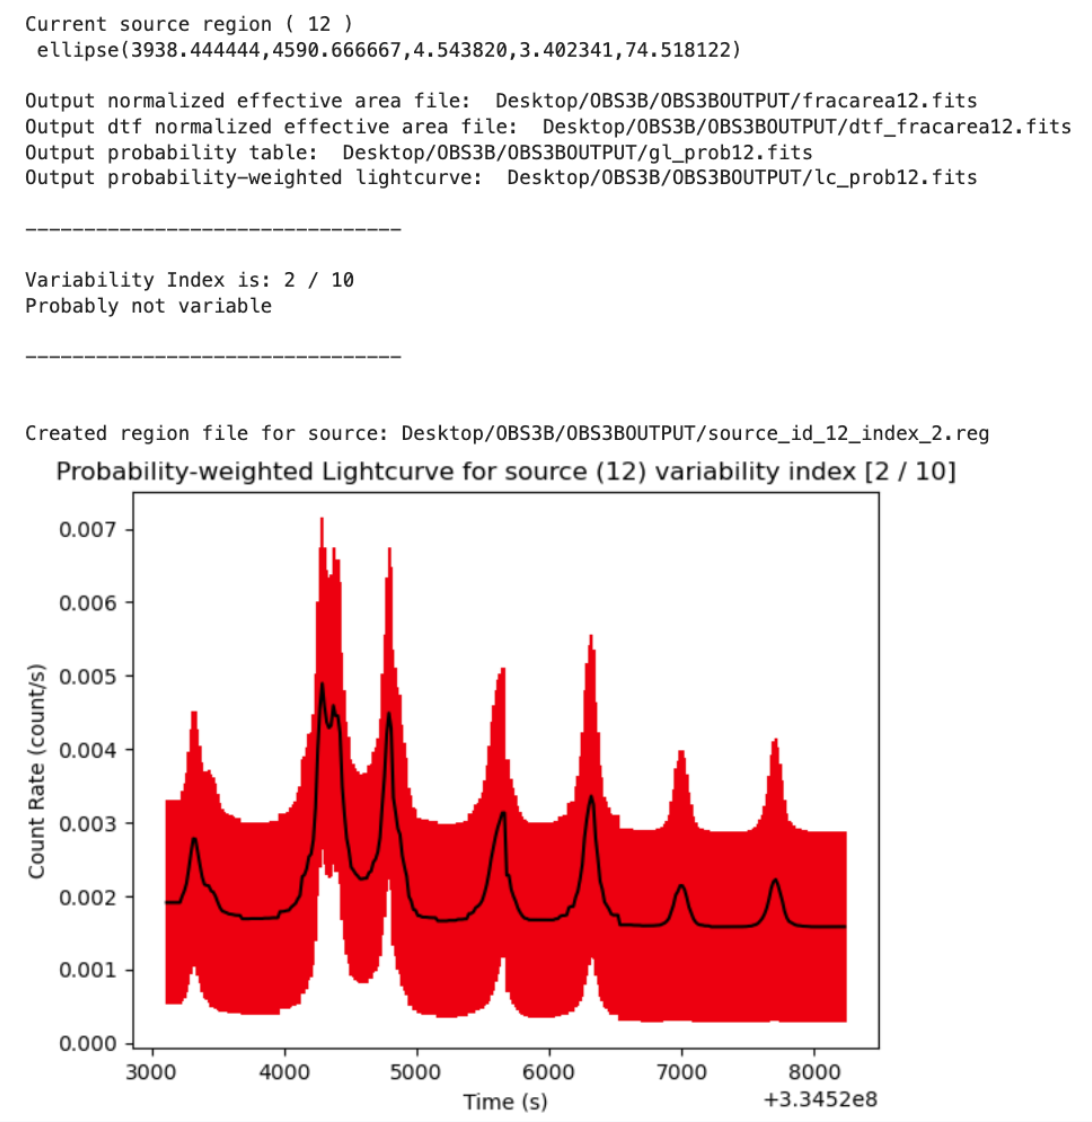

A new region file will be created for each individual source in the input region file:

(This is an individual source’s region file and the event file displayed in js9)

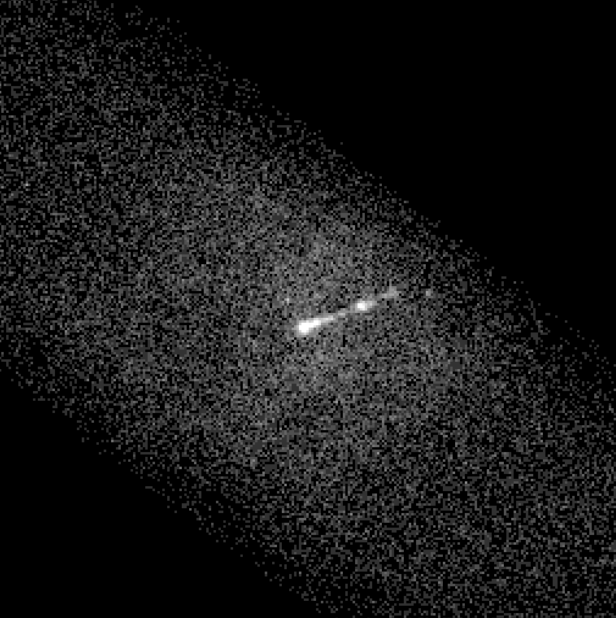

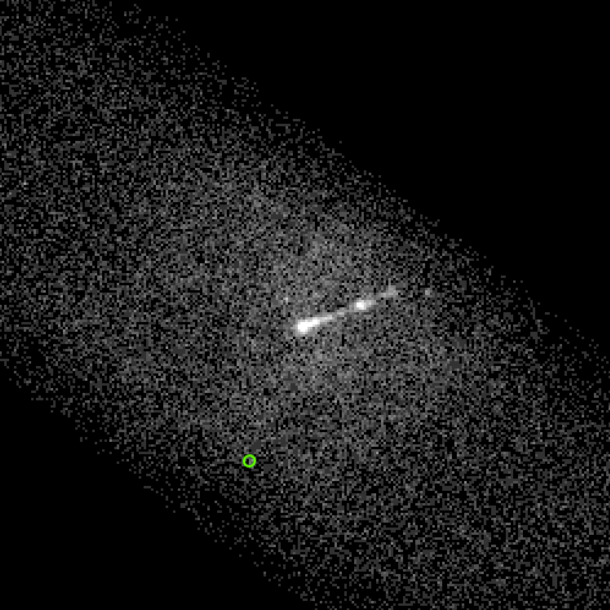

The variability index comes from a table in this (https://cxc.cfa.harvard.edu/ciao/threads/variable/) ciao thread.

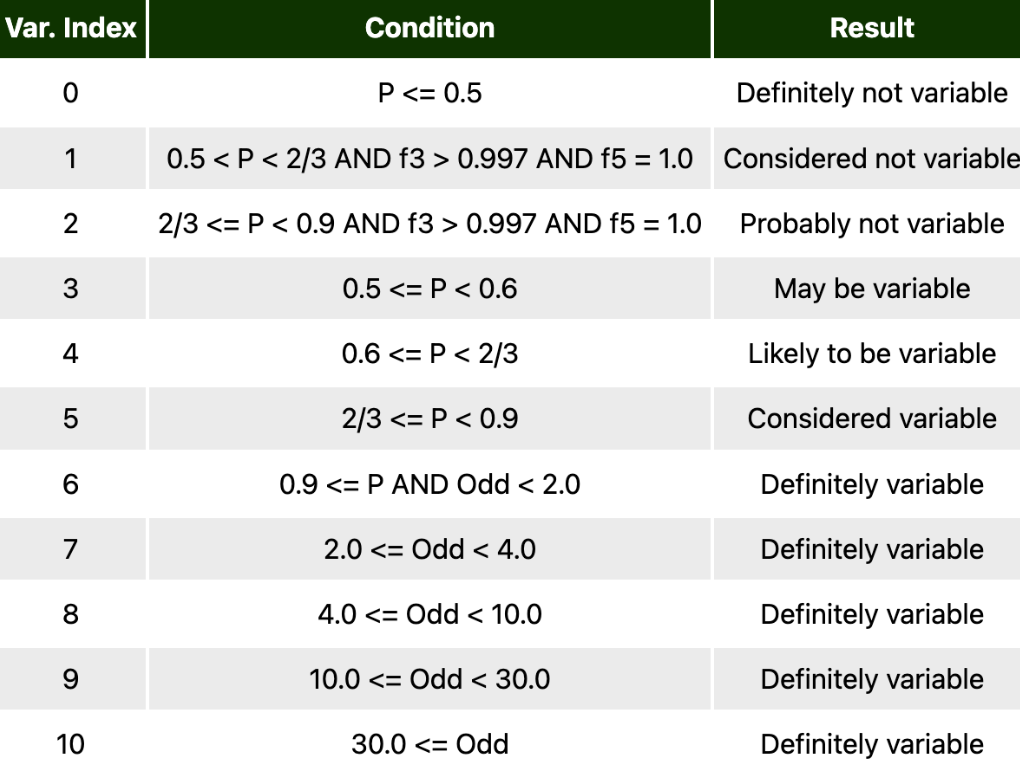

### Code:

In [ ]:
#This module does the following:
#Uses variables/files from the User Input/Source Detection Modules.
#Places all newly created files in the user-specified "outputDataFolderPath"
#Stores the location of the aspect solution "asol1.fits" file in the variable "variabilityInputAsol1File"
#Stores the location of the bad pixel "bpix1.fits" file in the variable "variabilityInputBpix1File"
#Stores the location of the mask "msk1.fits" file in the variable "variabilityInputMsk1File"          
#Iterates through each source found by the Source Detection Module, and creates the following files for each source: 
#A normalized effective area file "ditherOutfile", formatted as "outputDataFolderPath/fracarea{source number}.fits"
#A dead time corrected normalized effective area file "deadTimeOutfile", formatted as "outputDataFolderPath/dtf_fracarea{source number}.fits"
#A probability table "glvaryOutfile", formatted as "outputDataFolderPath/gl_prob{source number}.fits"
#A probability-weighted lightcurve "glvaryLcfile", formatted as "outputDataFolderPath/lc_prob{source number}.fits"
#Outputs the source's variability index and a string describing how likely the source is to be variable.
#Plots the probability-weighted lightcurve "glvaryLcfile" for each source.
#All individual sources are saved as new region files to "outputDataFolderPath/variable_source_id_{source number}_index_{variability index}.reg"
        
#Import modules:

from ciao_contrib import runtool as rt
from subprocess import *
import os
from pathlib import Path
from os import listdir
from os.path import isfile, join
from lightcurves import *
from paramio import *
import paramio
from pycrates import read_file

#This is a bandaid fix needed to clear any previous plots and fix some issues with matplotlib. Remove if matplotlib isn’t causing any issues.
%matplotlib inline 
import matplotlib.pyplot as plt
plt.clf()

#Define functions:

#Returns a string describing how likely a source is to be variable, depending on the variability index. Based on a table provided in this CIAO thread:
#https://cxc.cfa.harvard.edu/ciao/threads/variable/
def variability_index_description(index): 
    print("\n--------------------------------\n") #Filler line to make the variability description stand out more than the rest of the text output.
    print("Variability Index is:", index, "/ 10") 
    
    if index==0:
        print("Definitely not variable")
    if index==1:
        print("Considered not variable")
    if index==2:
        print("Probably not variable")    
    if index==3:
        print("May be variable")
    if index==4:
        print("Likely to be variable")
    if index==5:
        print("!Considered variable!")
    if index>5:
        print("!!!Definitely variable!!!")
        
    print("\n--------------------------------\n")

#Set variables:

variabilityInputEvt2File = inputEventFile
variabilityInputAsol1File = ""
variabilityInputBpix1File = ""
variabilityInputMsk1File = ""
variabilityOutfile = ""

#This is the folder where asol1/bpix1 files are located.
inputPrimaryDataFolderPath = inputDataFolderPath+"/primary/" 

#This is the folder where the msk1 file is located.
inputSecondaryDataFolderPath = inputDataFolderPath+"/secondary/" 

#Locating the asol1 file(based on the same locator code as in the Source Detection Module):
#This code can be turned into a function if it's needed very frequently.

fileFound = False
FILE_END_STRING = "asol1"
FITS_FILE_EXTENSION = ".fits"

fileNamesList = [file for file in listdir(inputPrimaryDataFolderPath) if isfile(join(inputPrimaryDataFolderPath, file))]
filePathsList = [inputPrimaryDataFolderPath+fileName for fileName in fileNamesList]

for file in filePathsList:
    
    if FILE_END_STRING in file and FITS_FILE_EXTENSION in file:
        variabilityInputAsol1File = file
        fileFound = True
        
        print("asol1 file located at:", variabilityInputAsol1File)
        break

if fileFound == False:
    print("\nInput folder", inputPrimaryDataFolderPath, "\ndoes not contain a file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the file was renamed.")
    raise SystemExit("Input folder", inputPrimaryDataFolderPath, "does not contain a file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the file was renamed.")

#Locating the bpix1 file:

fileFound = False
FILE_END_STRING = "bpix1"
FITS_FILE_EXTENSION = ".fits"

fileNamesList = [file for file in listdir(inputPrimaryDataFolderPath) if isfile(join(inputPrimaryDataFolderPath, file))]
filePathsList = [inputPrimaryDataFolderPath+fileName for fileName in fileNamesList]

for file in filePathsList:
    
    if FILE_END_STRING in file and FITS_FILE_EXTENSION in file:
        variabilityInputBpix1File = file
        fileFound = True
        
        print("bpix1 file located at:", variabilityInputBpix1File)
        break

if fileFound == False:
    print("\nInput folder", inputPrimaryDataFolderPath, "\ndoes not contain a file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the file was renamed.")
    raise SystemExit("Input folder", inputPrimaryDataFolderPath, "does not contain a file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the file was renamed.")

#Locating the msk1 file:

fileFound = False
FILE_END_STRING = "msk1"
FITS_FILE_EXTENSION = ".fits"

fileNamesList = [file for file in listdir(inputSecondaryDataFolderPath) if isfile(join(inputSecondaryDataFolderPath, file))]
filePathsList = [inputSecondaryDataFolderPath+fileName for fileName in fileNamesList]

for file in filePathsList:
    
    if FILE_END_STRING in file and FITS_FILE_EXTENSION in file:
        variabilityInputMsk1File = file
        fileFound = True
        
        print("msk1 file located at:", variabilityInputMsk1File)
        break

if fileFound == False:
    print("\nInput folder", inputSecondaryDataFolderPath, "\ndoes not contain a file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the file was renamed.")
    raise SystemExit("Input folder", inputSecondaryDataFolderPath, "does not contain a file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the file was renamed.")

#Setting the “ardlib” parameter file, required for dither_region:

call(["punlearn", "ardlib"])
call(["acis_set_ardlib", variabilityInputBpix1File, "abs-"])

#Set most of the other parameters for dither_region:

ditherInfile = variabilityInputAsol1File
ditherWcsfile = variabilityInputEvt2File
ditherMaskfile = variabilityInputMsk1File

punlearn("dither_region")
pset("dither_region", "maskfile", ditherMaskfile)

#Get the dead time correction:

call(["dmkeypar", variabilityInputEvt2File, "DTCOR"])
dtc = pget("dmkeypar", "rval")
print("Dead time correction:", dtc)

#How variability is checked for each source:
#Loop through each source region in the list of regions, "regionList", made by the Source Detection Module,
#Create a normalized effective area file using dither_region for each source in the list,
#Then set the dead time correction,
#Then use glvary to check for variability:

print("Checking variability for", len(regionList), "sources:\n")
i = 1
while i <= len(regionList):
    
    #Create the normalized effective area file:
    
    variabilityOutfile = outputDataFolderPath+"/fracarea"+str(i)+".fits"
    ditherOutfile = variabilityOutfile
    currentRegion = regionList[i-1]

    #Check if the region has a radius of zero; this could accidentally flag other strings that have another value (not the radius) that happens to also be exactly zero, but the odds of this happening are low. This code should be removed or replaced as it WILL flag and remove otherwise valid sources in large enough source lists.
    if ",0.000000" in regionList[i-1]:
        print("Source region (", i, ") has a radius of zero, skipping")
        i+=1
        continue
    
    print("\nCurrent source region (", i, ")\n", regionList[i-1])
    
    call(["dither_region", ditherInfile, currentRegion, ditherOutfile, ditherWcsfile, "clobber=yes"])
    print("\nOutput normalized effective area file: ", ditherOutfile)

    #Dead time correction:
    
    deadTimeInfile = outputDataFolderPath+"/fracarea"+str(i)+".fits"
    deadTimeOutfile = outputDataFolderPath+"/dtf_fracarea"+str(i)+".fits"
    deadTimeExpression = "expression=dtf=("+dtc+"*fracarea)"

    call(["dmtcalc", deadTimeInfile+"[cols time,fracarea]", deadTimeOutfile, deadTimeExpression, "clob+"])
    print("Output dtf normalized effective area file: ", deadTimeOutfile)   
    
    #Check variability; creates a probability-weighted lightcurve (lc_prob.fits),
    #and a table of output probabilities (gl_prob.fits):

    glvaryInfile = variabilityInputEvt2File+"[sky="+currentRegion+"]" #The ccd_id is not specified in this line, so it uses the default value instead. 
    glvaryEffile = deadTimeOutfile
    glvaryOutfile = outputDataFolderPath+"/gl_prob"+str(i)+".fits"
    glvaryLcfile = outputDataFolderPath+"/lc_prob"+str(i)+".fits"

    call(["glvary", glvaryInfile, glvaryOutfile, glvaryLcfile, glvaryEffile, "clobber=yes"])
    print("Output probability table: ", glvaryOutfile, "\nOutput probability-weighted lightcurve: ", glvaryLcfile)

    #Check if any output files were created, then proceed; this fixes issues with regions that have an area of zero due to them having a radius of zero:
    if Path(glvaryOutfile).exists():
    
        #Output information about variability of source:

        HDUList = fits.open(glvaryOutfile) #Open .fits file, save data as an HDUList object,
        data = HDUList[1].header #Index 1 is where variability info is,
        HDUList.close() #Close the HDUList.

        variability_index_description(data[23]) #Calling this function to print a string describing the variability of the source. Index 23 is where the variability index is located in the header of "glvaryOutfile" / the probability table.
    
        #Make a new region file containing only the current source region:
        #NOTE: This region file can be loaded in js9/ds9 with the original event file to visually locate the source.
        
        sourceRegionOutfile = outputDataFolderPath+"/source_id_"+str(i)+"_index_"+str(data[23])+".reg"
        call(["punlearn", "dmmakereg"])
        call(["pset", "dmmakereg", "kernel=ascii"])
        call(["dmmakereg", currentRegion, sourceRegionOutfile, "clobber=yes"])
        print("\nCreated region file for source:", sourceRegionOutfile)

        #Make the plot of the probability-weighted lightcurve:
        
        tab = read_file(glvaryLcfile)
        xx = tab.get_column("Time").values
        yy = tab.get_column("COUNT_RATE").values
        ye = tab.get_column("COUNT_RATE_ERR").values
        plotTitle = "Probability-weighted Lightcurve for source ("+str(i)+") variability index ["+str(data[23])+" / 10]"

        plt.xlabel("Time (s)")
        plt.ylabel("Count Rate (count/s)")
        plt.title(plotTitle)
        
        plt.errorbar(xx,yy,yerr=ye, ecolor="red", color="black")
        plt.show()
    
        print("\n")
    
    i+=1
